In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import numpy as np
import tqdm
import datetime

pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_colwidth', 5000)

import plotly.io as pio
pio.templates.default = 'simple_white'
from bertopic import BERTopic

## Loading data

In [3]:
df = pd.read_csv('hotel_reviews_with_transl.csv', sep = '\t')
df.sample(3)

,id,hotel,review,lang,reviews_transl,reviews_len
7594,7997,Hilton,"#1 choice to stay on our next visit to London My husband and I traveled for two weeks on vacation in Europe. In London we stayed for 3 days in this hotel and then 3 days in the Hilton Waldorf in the West End. Must say this hotel is the one we would definitely return to. My husband is a HHonors Diamond member and we were upgraded to an Executive Suite. The room was immaculately clean, modern, and had a nice view of the area. The location is superb as the hotel is located a stones throw away from the DLR &amp; and the Tube. We didn't mind at all taking the metro to go to the main tourist areas. We ate at the restaurant which is okay and somewhat bland; nothing to call home about. Comparing both of the Hilton properties we stayed in during our trip to London we will our choice for all return visits is the London Canary Wharf.",en,"#1 choice to stay on our next visit to London My husband and I traveled for two weeks on vacation in Europe. In London we stayed for 3 days in this hotel and then 3 days in the Hilton Waldorf in the West End. Must say this hotel is the one we would definitely return to. My husband is a HHonors Diamond member and we were upgraded to an Executive Suite. The room was immaculately clean, modern, and had a nice view of the area. The location is superb as the hotel is located a stones throw away from the DLR &amp; and the Tube. We didn't mind at all taking the metro to go to the main tourist areas. We ate at the restaurant which is okay and somewhat bland; nothing to call home about. Comparing both of the Hilton properties we stayed in during our trip to London we will our choice for all return visits is the London Canary Wharf.",834
11352,11941,Radisson,"Modern business hotel near Canary Wharf This hotel is a modern business hotel within ten minutes walk of Canary Wharf. It is found on the north bank of the Thames, opposite the O2 arena. Unless you are staying on business or wishing to attend a concert, I struggle to see why you would stay here. Having said this, the hotel is modern (Bang &amp; Olufsen televisions in the room), clean and well proportioned. The restaurant is reasonable value however the hotel clearly markets itself to visitors to Canary Wharf with prices to match. An enjoyable stay, but unlikely to be repeated unless I intend to travel to Canary Wharf.",en,"Modern business hotel near Canary Wharf This hotel is a modern business hotel within ten minutes walk of Canary Wharf. It is found on the north bank of the Thames, opposite the O2 arena. Unless you are staying on business or wishing to attend a concert, I struggle to see why you would stay here. Having said this, the hotel is modern (Bang &amp; Olufsen televisions in the room), clean and well proportioned. The restaurant is reasonable value however the hotel clearly markets itself to visitors to Canary Wharf with prices to match. An enjoyable stay, but unlikely to be repeated unless I intend to travel to Canary Wharf.",625
2527,2668,Hilton,"Outdated overpriced and hard to get to As many have pointed out, the hotel is not near any tube station - Canada Water is a good 5 minutes by the shuttle which leaves every 15 minutes starting from 7 am. If you have an early morning flight you're out of luck. The rooms are dated, the heating oppressive (I stayed in 2232 in the main wing) with a sticker next to the thermostat stating that it controls both heating and cooling - it did nothing with the result I had to open the windows to let in cold air. The views are unimpressive as well as they overlook a residential building across the canal in front of the hotel. The room itself was smallish with carpet that was clean but very dated. I had asked for a non-smoking room and, in fact the entire second floor is supposedly a non-smoking floor but the room was smelling of cigarette smoke as was the case with the linen including the towels. When I informed the duty manager, he asked &quot;are 

In [4]:
docs = list(df.reviews_transl)
docs[:3]

["We stayed three nights over Thanksgiving weekend. While it's a ways out of downtown London, the little town it's in is great--lots of delicious restaurants, inexpensive shopping, close to a fairly major highway. Our two rooms were spare but comfortable and very clean. Bathrooms were fine. Mattresses were sad, saggy and lumpy, but at least not rock hard and the sheets fit and stayed on well. The comforter was just the perfect weight for the weather--we all slept well. There's an in-house restaurant with room service, which we never had a chance to use. The a la carte prices were reasonable, except the buffet breakfast, which was high. It's difficult to find the parking lots, but once you figure out the one way streets and round-abouts, there is safe, adequate parking. We'd go back. For only nine pounds a night for two people, it's a great bargain!",
 "very uncomfortable stay We were staying at his hotel only because my father couldnt make it and rather than cancel the rooms we took hi

## Building default model

In [5]:
%%time

# Create a BERTopic model and fit it to the documents
topic_model = BERTopic()
topics, ini_probs = topic_model.fit_transform(docs)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CPU times: user 20min 22s, sys: 27.5 s, total: 20min 50s
Wall time: 3min 44s


In [6]:
# Get the number of topics. -1 because of the -1 topic for outliers.
num_topics = len(topic_model.get_topics()) - 1
num_topics

104

In [ ]:
# Get the topic information and display the top 10 topics
# 6343 reviews were not assigned to any topic and are labeled as -1 (outliers).
topic_model.get_topic_info().head(10).set_index('Topic')[['Count', 'Name', 'Representation']]

,Count,Name,Representation
Topic,,,
-1,6743,-1_the_and_was_to,"[the, and, was, to, in, of, for, we, room, hotel]"
0,295,0_london_hotel_great_location,"[london, hotel, great, location, stay, and, nice, in, good, is]"
1,230,1_paddington_heathrow_station_hilton,"[paddington, heathrow, station, hilton, express, the, to, is, and, in]"
2,195,2_hilton_london_the_is,"[hilton, london, the, is, bridge, and, of, to, in, was]"
3,186,3_victoria_plaza_park_station,"[victoria, plaza, park, station, and, the, hotel, we, great, london]"
4,182,4_great_hotel_staff_stay,"[great, hotel, staff, stay, very, excellent, friendly, here, nice, location]"
5,166,5_gloucester_tube_road_is,"[gloucester, tube, road, is, and, the, hotel, location, great, station]"
6,156,6_covent_garden_location_holborn,"[covent, garden, location, holborn, travelodge, great, for, and, you, is]"
7,131,7_dirty_was_the_had,"[dirty, was, the, had, to, that, room, it, my, not]"


In [8]:
topic_model.visualize_barchart(top_n_topics = 16, n_words = 10)

In [9]:
# クラスごとのトピック分布を計算し、可視化する
# normalize_frequency = True の解釈については以下を参照: 各クラスまたは各トピックの値の合計を 1 にするものではなく、
# トピック間の相対的なトレンドを比較しやすくするために、トピックごとに各クラスの頻度ベクトルを L2 正規化をしているだけ
# https://github.com/MaartenGr/BERTopic/issues/446
# https://github.com/MaartenGr/BERTopic/blob/de7376d3d42960e787a1115e5fe69fb726a7a33d/bertopic/plotting/_topics_per_class.py#L90
topics_per_class = topic_model.topics_per_class(docs, classes=df.hotel)
fig = topic_model.visualize_topics_per_class(
    topics_per_class,
    top_n_topics=10,
    normalize_frequency = True
)

fig.write_html('basic.html')
fig.show()

In [10]:
# 各レビューに割り当てられたトピックをデータフレームに追加
df['basic_topic'] = topics

## Dealing with the outliers

### Improving the topic model

In [11]:
def get_topic_stats(topic_model, extra_cols = []):
    topics_info_df = topic_model.get_topic_info().sort_values('Count', ascending = False)
    topics_info_df['Share'] = 100.*topics_info_df['Count']/topics_info_df['Count'].sum()
    topics_info_df['CumulativeShare'] = 100.*topics_info_df['Count'].cumsum()/topics_info_df['Count'].sum()
    return topics_info_df[['Topic', 'Count', 'Share', 'CumulativeShare', 'Name', 'Representation'] + extra_cols]

In [12]:
!uv pip install pip
!uv run python -m spacy download en_core_web_sm

Using Python 3.13.12 environment at: /workspace/.venv
Checked 1 package in 33ms
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 12.2 MB/s  0:00:01 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [13]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [14]:
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.representation import KeyBERTInspired, PartOfSpeech, MaximalMarginalRelevance

main_representation_model = KeyBERTInspired()
aspect_representation_model1 = PartOfSpeech("en_core_web_sm")
aspect_representation_model2 = [KeyBERTInspired(top_n_words=30), MaximalMarginalRelevance(diversity=.5)]

representation_model = {
   "Main": main_representation_model,
   "Aspect1":  aspect_representation_model1,
   "Aspect2":  aspect_representation_model2 
}

vectorizer_model = CountVectorizer(min_df=5, stop_words = 'english')
topic_model = BERTopic(nr_topics = 'auto',
                       vectorizer_model = vectorizer_model,
                       representation_model = representation_model)
topics, ini_probs = topic_model.fit_transform(docs)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [15]:
num_topics = len(topic_model.get_topics()) - 1
num_topics

71

In [16]:
get_topic_stats(topic_model, ['Aspect1', 'Aspect2']).head(7).set_index('Topic')

,Count,Share,CumulativeShare,Name,Representation,Aspect1,Aspect2
Topic,,,,,,,
-1,6607,53.94,53.94,-1_hotels_hotel_london_rooms,"[hotels, hotel, london, rooms, inn, room, restaurant, bathroom, place, bed]","[room, hotel, good, breakfast, staff, stay, location, great, night, rooms]","[hotels, london, room, restaurant, booked, travelodge, bus, station, shower, park]"
0,2313,18.88,72.82,0_hotel_hotels_london_rooms,"[hotel, hotels, london, rooms, hilton, heathrow, paddington, covent, restaurant, room]","[hotel, great, good, room, location, stay, staff, breakfast, nice, rooms]","[hotels, rooms, heathrow, paddington, covent, booked, bar, bathroom, weekend, recommend]"
1,192,1.57,74.39,1_victoria_park_london_hotel,"[victoria, park, london, hotel, palace, buckingham, hotels, station, gatwick, city]","[plaza, park, station, great, hotel, location, modern, nice, palace, walk]","[park, hotel, palace, buckingham, gatwick, lounge, plaza, located, bathrooms, coffee]"
2,181,1.48,75.87,2_gloucester_hotels_hotel_london,"[gloucester, hotels, hotel, london, rooms, inn, pubs, restaurants, restaurant, nearby]","[gloucester, tube, road, millennium, location, great, station, hotel, restaurants, room]","[gloucester, hotels, london, pubs, tesco, shops, booked, kensington, reviews, museum]"
3,165,1.35,77.21,3_rooms_hotel_room_bathroom,"[rooms, hotel, room, bathroom, bed, shower, bath, smell, walls, carpets]","[dirty, room, shower, bathroom, smell, reception, air, floor, bed, night]","[rooms, hotel, shower, smell, walls, carpets, toilet, mold, stains, filthy]"
4,136,1.11,78.32,4_noisy_noise_hotel_rooms,"[noisy, noise, hotel, rooms, quieter, room, quiet, bed, london, nights]","[noisy, noise, sleep, night, room, road, hotel, people, loud, window]","[noisy, rooms, london, nights, nightclub, doors, reception, earplugs, travelodge, sleeper]"
5,130,1.06,79.39,5_bonnington_hotel_hotels_rooms,"[bonnington, hotel, hotels, rooms, london, room, stayed, beds, covent, restaurant]","[bonnington, breakfast, room, museum, hotel, great, stay, good, trip, single]","[bonnington, hotel, london, stayed, beds, bloomsbury, stations, reviews, bathroom, desk]"


In [17]:
topic_model.visualize_barchart(top_n_topics = 16, n_words = 10)

In [18]:
df['basic_topic'] = topics

In [19]:
topic_model.visualize_topics()

### Reducing the number of topics

#### Finding similar topics
https://github.com/MaartenGr/BERTopic/issues/292

In [20]:
topic_model.visualize_heatmap(n_clusters = 20)

In [21]:
from sklearn.metrics.pairwise import cosine_similarity

In [22]:
# トピック埋め込みのコサイン類似度行列を計算
distance_matrix = cosine_similarity(np.array(topic_model.topic_embeddings_))

In [23]:
# コサイン類似度行列をデータフレームに変換
dist_df = pd.DataFrame(distance_matrix,
                       columns=topic_model.topic_labels_.values(), 
                       index=topic_model.topic_labels_.values())

In [24]:
# コサイン類似度行列をトピックペアの距離データフレームに変換
tmp = []
for rec in dist_df.reset_index().to_dict('records'):
    t1 = rec['index']
    for t2 in rec:
        if t2 == 'index': 
            continue
        tmp.append(
            {
                'topic1': t1, 
                'topic2': t2, 
                'distance': rec[t2]
            }
        )

pair_dist_df = pd.DataFrame(tmp)

In [25]:
pair_dist_df

,topic1,topic2,distance
0,-1_hotels_hotel_london_rooms,-1_hotels_hotel_london_rooms,1.00
1,-1_hotels_hotel_london_rooms,0_hotel_hotels_london_rooms,0.99
2,-1_hotels_hotel_london_rooms,1_victoria_park_london_hotel,0.87
3,-1_hotels_hotel_london_rooms,2_gloucester_hotels_hotel_london,0.89
4,-1_hotels_hotel_london_rooms,3_rooms_hotel_room_bathroom,0.80
...,...,...,...
5179,70_hotel_accommodation_lounge_bedroom,66_hotel_bedroom_booking_room,0.72
5180,70_hotel_accommodation_lounge_bedroom,67_hotel_hotels_hilton_rooms,0.74
5181,70_hotel_accommodation_lounge_bedroom,68_hotel_london_covent_rooms,0.69
5182,70_hotel_accommodation_lounge_bedroom,69_dining_booking_restaurant_drinks,0.62


In [26]:
# -1 トピックを除外
pair_dist_df = pair_dist_df[
    (pair_dist_df.topic1.map(lambda x: not x.startswith('-1'))) & 
    (pair_dist_df.topic2.map(lambda x: not x.startswith('-1')))
]

In [27]:
# トピックペアの距離データフレームから、トピック1 < トピック2 の条件を満たす行のみを抽出
pair_dist_df = pair_dist_df[pair_dist_df.topic1 < pair_dist_df.topic2]

In [28]:
# トピックペアの距離データフレームを距離の降順でソートし、上位30件を表示
pair_dist_df.sort_values('distance', ascending = False).head(30)

,topic1,topic2,distance
82,0_hotel_hotels_london_rooms,9_oxford_hotel_hotels_rooms,0.92
424,4_noisy_noise_hotel_rooms,63_hotel_room_hotels_noise,0.92
2337,31_hotels_hotel_rooms_radisson,32_hotel_hotels_soho_rooms,0.92
1996,26_hotel_hotels_heathrow_london,51_hotel_wireless_wifi_internet,0.90
94,0_hotel_hotels_london_rooms,21_islington_hotels_hotel_london,0.90
75,0_hotel_hotels_london_rooms,2_gloucester_hotels_hotel_london,0.90
106,0_hotel_hotels_london_rooms,33_london_hotel_heathrow_earls,0.89
74,0_hotel_hotels_london_rooms,1_victoria_park_london_hotel,0.89
81,0_hotel_hotels_london_rooms,8_hotels_hotel_euston_hilton,0.89
108,0_hotel_hotels_london_rooms,35_hotels_hotel_restaurant_cafe,0.89


In [29]:
# トピックをマージ
topic_model.merge_topics(docs, [[0, 2, 9, 21], [4, 63], [31, 32], [26, 51]])

In [30]:
def get_topic_representation(topic_model, topic):
    data = topic_model.get_topic(topic)
    
    return ', '.join(list(map(lambda x: x[0], data)))

# トピックのマージ後のトピック割り当てをデータフレームに追加
df['merged_topic'] = topic_model.topics_
df['merged_topic_repr'] = df['merged_topic'].map(lambda x: get_topic_representation(topic_model, x))

In [31]:
# マージ前とマージ後のトピック割り当ての違いを確認
df[df.merged_topic != df.basic_topic].shape[0], df.merged_topic.nunique()

(2954, 66)

In [32]:
num_topics = len(topic_model.get_topics()) - 1
num_topics

65

In [33]:
get_topic_stats(topic_model).head(10)

,Topic,Count,Share,CumulativeShare,Name,Representation
0,-1,6607,53.94,53.94,-1_hotels_hotel_london_rooms,"[hotels, hotel, london, rooms, inn, room, restaurant, bathroom, place, bed]"
1,0,2659,21.71,75.65,0_hotel_hotels_london_hilton,"[hotel, hotels, london, hilton, heathrow, rooms, paddington, covent, room, booked]"
2,1,192,1.57,77.21,1_victoria_park_london_buckingham,"[victoria, park, london, buckingham, palace, hotel, hotels, station, gatwick, plaza]"
3,2,165,1.35,78.56,2_rooms_hotel_room_bathroom,"[rooms, hotel, room, bathroom, bed, shower, bath, smell, walls, carpets]"
4,3,148,1.21,79.77,3_noisy_noise_hotel_hotels,"[noisy, noise, hotel, hotels, rooms, room, quiet, bed, nights, loud]"
5,4,130,1.06,80.83,4_hotels_hotel_rooms_room,"[hotels, hotel, rooms, room, cigarette, smokers, smoke, smoking, london, gloucester]"
6,5,130,1.06,81.89,5_bonnington_hotel_hotels_rooms,"[bonnington, hotel, hotels, rooms, london, room, stayed, beds, covent, restaurant]"
7,6,119,0.97,82.86,6_mayfair_london_hotel_hotels,"[mayfair, london, hotel, hotels, piccadilly, buckingham, restaurants, restaurant, inn, palace]"
8,7,117,0.96,83.82,7_hotels_hotel_euston_hilton,"[hotels, hotel, euston, hilton, rooms, london, room, restaurant, travelodge, booked]"
9,8,103,0.84,84.66,8_hotel_o2_rooms_visiting,"[hotel, o2, rooms, visiting, facilities, london, concert, arena, booked, greenwich]"


In [34]:
topic_model.visualize_barchart(top_n_topics = 16, n_words = 10)

In [35]:
topic_model.visualize_topics()

### Approximate Topic Distributions
https://maartengr.github.io/BERTopic/getting_started/distribution/distribution.html

In [36]:
# トピック分布の近似を計算
# topic_distr: 各ドキュメントに対するトピックの分布（確率）
# topic_token_distr: 各ドキュメントに対するトピックごとのトークンの分布（確率）
topic_distr, topic_token_distr = topic_model.approximate_distribution(docs, window = 4, calculate_tokens=True)

In [37]:
# 文書トピック分布と文書のトークンレベルのトピック分布の形状を確認
topic_distr.shape, topic_token_distr[0].shape, topic_token_distr[1].shape

((12249, 65), (145, 65), (323, 65))

Text(0.5, 1.0, 'Distribution of topic non-zero probabilities')

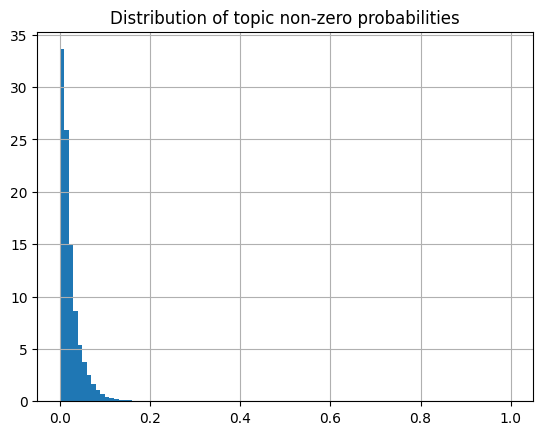

In [38]:
# topic_distr の非ゼロの値の分布をヒストグラムで表示
raw_distr = pd.Series(topic_distr.ravel())
raw_distr = raw_distr[raw_distr > 0]

ax = raw_distr.hist(bins = 100, range = [0, 1], weights = np.ones_like(raw_distr)*100/raw_distr.shape[0])
ax.set_title('Distribution of topic non-zero probabilities')

In [39]:
# 各ドキュメントに対するトピックの分布の最大値をデータフレームに追加
df['max_topic_distr'] = topic_distr.max(axis = 1)

In [40]:
# 各ドキュメントに対するトピックの分布の最大値が 0.05 より大きいドキュメントの割合を計算
1 - df[df.max_topic_distr > 0.05].shape[0]/df.shape[0]

0.007592456527063418

In [41]:
df = df.reset_index(drop=True)

In [42]:
# 各ドキュメントに対するトピックの分布の最大値が 0.1 より大きく、かつレビューの長さが 100 以下のドキュメントをランダムに 10 件表示
df[(df.max_topic_distr > 0.1) & (df.reviews_len <= 200)].sort_values('reviews_len', ascending = False).head(10)

,id,hotel,review,lang,reviews_transl,reviews_len,basic_topic,merged_topic,merged_topic_repr,max_topic_distr
2155,2282,Radisson,"excellent locationbreakfast brilliant and definitely will be returning central location for covent garden and surrounding areas, all in walking distance. theatres all nearby good pubs and restaurants.",en,"excellent locationbreakfast brilliant and definitely will be returning central location for covent garden and surrounding areas, all in walking distance. theatres all nearby good pubs and restaurants.",200,0,0,"hotel, hotels, london, hilton, heathrow, rooms, paddington, covent, room, booked",0.36
8244,8666,Hilton,"Would never go there again This is the WORST hotel I have ever stayed in. Dirty and old, roach infested and my boyfriend got eaten alive by fleas. Nothing worked- a/c, shower etc. Absolutely horrible.",en,"Would never go there again This is the WORST hotel I have ever stayed in. Dirty and old, roach infested and my boyfriend got eaten alive by fleas. Nothing worked- a/c, shower etc. Absolutely horrible.",200,-1,-1,"hotels, hotel, london, rooms, inn, room, restaurant, bathroom, place, bed",0.30
5144,5405,Hilton,Fantastic hotel I have stayed at the hotel a few times now and it is the best connected hotel via Heathrow and through Paddington Station to the south west. Rooms are excellent and service is great!!,en,Fantastic hotel I have stayed at the hotel a few times now and it is the best connected hotel via Heathrow and through Paddington Station to the south west. Rooms are excellent and service is great!!,199,0,0,"hotel, hotels, london, hilton, heathrow, rooms, paddington, covent, room, booked",0.12
5740,6034,Travelodge,"Good location ok acommodation. Not as bad as some of the reviews suggest, location good as Kings cross is a main Tube station. Maybe not up to the standard of regular travelodges. Room well serviced.",en,"Good location ok acommodation. Not as bad as some of the reviews suggest, location good as Kings cross is a main Tube station. Maybe not up to the standard of regular travelodges. Room well serviced.",199,-1,-1,"hotels, hotel, london, rooms, inn, room, restaurant, bathroom, place, bed",0.27
11041,11623,Radisson,"Warm comfortable hotel and staff very friendly. Hotel is warm, comfortable and the staff are very friendly. The breakfast buffet is organised efficiently and there is a wide choice of food and drink.",en,"Warm comfortable hotel and staff very friendly. Hotel is warm, comfortable and the staff are very friendly. The breakfast buffet is organised efficiently and there is a wide choice of food and drink.",199,0,0,"hotel, hotels, london, hilton, heathrow, rooms, paddington, covent, room, booked",0.21
2579,2720,Hilton,"Another great stay at Docklands This is my third stay at Hilton Docklands. I love the location, and the river view rooms in the Wharf Building really make the stay special. Staff always very helpful.",en,"Another great stay at Docklands This is my third stay at Hilton Docklands. I love the location, and the river view rooms in the Wharf Building really make the stay special. Staff always very helpful.",199,49,43,"hotels, hotel, docklands, hilton, hiltons, visiting, rooms, wharf, tourists, balcony",0.27
7007,7376,Radisson,An excellent place to stay We were well looked after from arrival to departure in this very stylishly furnished though still comfortable hotel.The food was was of a high standard as was the service.,en,An excellent place to stay We were well looked after from arrival to departure in this very stylishly furnished though still comfortable hotel.The food was was of a high standard as was the service.,198,-1,-1,"hotels, hotel, london, rooms, inn, room, restaurant, bathroom, place, bed",0.17
3990,4211,Radisson,They are really very helpful My stay at the Radission Edwardian Leicester Square Hotel was a very pleasant and enjoyable stay.The Staff is very helpful and willing to answer any question I may have.,en,They are really very helpful My st

In [43]:
doc_id = 2155

In [44]:
# doc_id のドキュメントに対するトピックの分布を可視化
topic_model.visualize_distribution(topic_distr[doc_id], min_probability=0.05)

In [45]:
# workaround for https://github.com/dexplo/dataframe_image/issues/74
print(pd.__version__)
pd.io.formats.style.Styler.applymap = pd.io.formats.style.Styler.map

3.0.1


In [46]:
docs[doc_id], topic_token_distr[doc_id].shape

('excellent locationbreakfast brilliant and definitely will be returning central location for covent garden and surrounding areas, all in walking distance. theatres all nearby good pubs and restaurants.',
 (27, 65))

In [47]:
# トークンレベルのトピック分布を可視化
## This example also shows that we might have spent more time merging topics because there are still pretty similar ones.
vis_df = topic_model.visualize_approximate_distribution(docs[doc_id], topic_token_distr[doc_id])
vis_df

,excellent,locationbreakfast,brilliant,and,definitely,will,be,returning,central,location,for,covent,garden,and,surrounding,areas,all,in,walking,distance,theatres,all,nearby,good,pubs,and,restaurants
0_hotel_hotels_london_hilton,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.112,0.219,0.219,0.219,0.107,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
16_hotels_hotel_rooms_london,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.105,0.238,0.351,0.351,0.246,0.113,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
21_location_located_place_city,0.000,0.000,0.000,0.000,0.000,0.000,0.151,0.302,0.483,0.610,0.459,0.308,0.127,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
33_hotels_hotel_marriott_hilton,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.102,0.205,0.314,0.314,0.212,0.109
37_hotel_accommodation_rooms_apartments,0.127,0.127,0.127,0.127,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
51_quality_price_value_discounted,0.166,0.166,0.166,0.289,0.123,0.123,0.123,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
60_mouse_room_rat_occupants,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.124,0.237,0.237,0.237,0.114,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
63_hotel_london_covent_rooms,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.181,0.341,0.498,0.607,0.426,0.266,0.109,0.000,0.000,0.163,0.325,0.466,0.607,0.445,0.282,0.141,0.000,0.000,0.000


In [48]:
# 確率が低すぎるトピックをフィルタリングするためのしきい値を決定する
# トピック分布の閾値を 0 から 0.15 まで 0.001 刻みで変化させながら、各ドキュメントに対して閾値以上のトピックの数をカウントし、その分布をデータフレームにまとめる
tmp_dfs = []

for thr in tqdm.tqdm(np.arange(0, 0.15, 0.001)):
    tmp_df = pd.DataFrame(list(map(lambda x: len(list(filter(lambda y: y >= thr, x))), topic_distr))).rename(
        columns = {0: 'num_topics'}
    )
    tmp_df['num_docs'] = 1
    tmp_df['num_topics_group'] = tmp_df['num_topics'].map(lambda x: str(x) if x < 5 else '5+')
    
    tmp_df_aggr = tmp_df.groupby('num_topics_group', as_index = False).num_docs.sum()
    tmp_df_aggr['threshold'] = thr
    
    tmp_dfs.append(tmp_df_aggr)

100%|██████████| 150/150 [00:07<00:00, 20.95it/s]


In [49]:
# トピック分布の閾値を変化させたときの、各トピック数グループ（0, 1, 2, 3, 4, 5+）のドキュメント数の分布をデータフレームにまとめる
num_topics_stats_df = pd.concat(tmp_dfs).pivot(
    index = 'threshold',
    values = 'num_docs',
    columns = 'num_topics_group'
).fillna(0)

In [50]:
# トピック分布の閾値を変化させたときの、各トピック数グループ（0, 1, 2, 3, 4, 5+）のドキュメント数の分布を割合で表示するために、各行を行ごとの合計で割る
num_topics_stats_df = num_topics_stats_df.apply(lambda x: 100.*x/num_topics_stats_df.sum(axis = 1))

In [51]:
print(pd.options.display.precision)

6


In [52]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
num_topics_stats_df

num_topics_group,0,1,2,3,4,5+
threshold,,,,,,
0.000,0.000,0.000,0.000,0.000,0.000,100.000
0.001,0.694,0.947,0.629,0.384,0.302,97.045
0.002,0.694,0.947,0.629,0.384,0.302,97.045
0.003,0.694,0.947,0.629,0.384,0.302,97.045
0.004,0.694,0.947,0.629,0.384,0.302,97.045
...,...,...,...,...,...,...
0.145,80.937,13.813,4.008,0.898,0.261,0.082
0.146,81.223,13.650,3.927,0.874,0.245,0.082
0.147,81.517,13.503,3.829,0.841,0.229,0.082


In [53]:
# トピック分布の閾値を変化させたときの、各トピック数グループ（0, 1, 2, 3, 4, 5+）のドキュメント数の分布を面グラフで表示
colormap = px.colors.sequential.YlGnBu
px.area(num_topics_stats_df, 
       title = 'Distribution of number of topics',
       labels = {'num_topics_group': 'number of topics', 'value': 'share of reviews, %'},
       color_discrete_map = {
          '0': colormap[0],
          '1': colormap[3],
          '2': colormap[4],
          '3': colormap[5],
          '4': colormap[6],
          '5+': colormap[7]
      })

In [54]:
threshold = 0.05

# 各ドキュメントに対するトピックの分布の閾値を 0.05 として、閾値以上のトピックを複数持つドキュメントを抽出し、そのトピックのリストをデータフレームに追加
df['multiple_topics'] = list(map(
    lambda doc_topic_distr: list(map(
        lambda y: y[0], filter(lambda x: x[1] >= threshold, 
                               (enumerate(doc_topic_distr)))
    )), topic_distr
))


tmp_data = []

# 複数トピックを持つドキュメントを複数行に展開し、トピックごとにドキュメントの情報を持つデータフレームを作成
for rec in df.to_dict('records'):
    if len(rec['multiple_topics']) != 0:
        mult_topics = rec['multiple_topics']
    else:
        mult_topics = [-1]

    for topic in mult_topics: 
        tmp_data.append(
            {
                'topic': topic,
                'id': rec['id'],
                'hotel': rec['hotel'],
                'reviews_transl': rec['reviews_transl']
            }
        )

mult_topics_df = pd.DataFrame(tmp_data)

In [55]:
mult_topics_df.head(10)

,topic,id,hotel,reviews_transl
0,0,0,Travelodge,"We stayed three nights over Thanksgiving weekend. While it's a ways out of downtown London, the little town it's in is great--lots of delicious restaurants, inexpensive shopping, close to a fairly major highway. Our two rooms were spare but comfortable and very clean. Bathrooms were fine. Mattresses were sad, saggy and lumpy, but at least not rock hard and the sheets fit and stayed on well. The comforter was just the perfect weight for the weather--we all slept well. There's an in-house restaurant with room service, which we never had a chance to use. The a la carte prices were reasonable, except the buffet breakfast, which was high. It's difficult to find the parking lots, but once you figure out the one way streets and round-abouts, there is safe, adequate parking. We'd go back. For only nine pounds a night for two people, it's a great bargain!"
1,21,0,Travelodge,"We stayed three nights over Thanksgiving weekend. While it's a ways out of downtown London, the little town it's in is great--lots of delicious restaurants, inexpensive shopping, close to a fairly major highway. Our two rooms were spare but comfortable and very clean. Bathrooms were fine. Mattresses were sad, saggy and lumpy, but at least not rock hard and the sheets fit and stayed on well. The comforter was just the perfect weight for the weather--we all slept well. There's an in-house restaurant with room service, which we never had a chance to use. The a la carte prices were reasonable, except the buffet breakfast, which was high. It's difficult to find the parking lots, but once you figure out the one way streets and round-abouts, there is safe, adequate parking. We'd go back. For only nine pounds a night for two people, it's a great bargain!"
2,24,0,Travelodge,"We stayed three nights over Thanksgiving weekend. While it's a ways out of downtown London, the little town it's in is great--lots of delicious restaurants, inexpensive shopping, close to a fairly major highway. Our two rooms were spare but comfortable and very clean. Bathrooms were fine. Mattresses were sad, saggy and lumpy, but at least not rock hard and the sheets fit and stayed on well. The comforter was just the perfect weight for the weather--we all slept well. There's an in-house restaurant with room service, which we never had a chance to use. The a la carte prices were reasonable, except the buffet breakfast, which was high. It's difficult to find the parking lots, but once you figure out the one way streets and round-abouts, there is safe, adequate parking. We'd go back. For only nine pounds a night for two people, it's a great bargain!"
3,27,0,Travelodge,"We stayed three nights over Thanksgiving weekend. While it's a ways out of downtown London, the little town it's in is great--lots of delicious restaurants, inexpensive shopping, close to a fairly major highway. Our two rooms were spare but comfortable and very clean. Bathrooms were fine. Mattresses were sad, saggy and lumpy, but at least not rock hard and the sheets fit and stayed on well. The comforter was just the perfect weight for the weather--we all slept well. There's an in-house restaurant with room service, which we never had a chance to use. The a la carte prices were reasonable, except the buffet breakfast, which was high. It's difficult to find the parking lots, but once you figure out the one way streets and round-abouts, there is safe, adequate parking. We'd go back. For only nine pounds a night for two people, it's a great bargain!"
4,34,0,Travelodge,"We stayed three nights over Thanksgiving weekend. While it's a ways out of downtown London, the little town it's in is great--lots of delicious restaurants, inexpensive shopping, close to a fairly major highway. Our two rooms were spare but comfortable and very clean. Bathrooms were fine. Mattresses were sad, saggy and lumpy, but at least not rock hard and the sheets fit and stayed on well. The comforter was just the perfect weight

## Comparing distributions by hotels

In [56]:
tmp_data = []

# ホテルごと、トピックごとに、ホテルのレビュー数、トピックを持つホテルのレビュー数、その他のホテルのレビュー数、その他のホテルでトピックを持つレビュー数を計算する
for hotel in mult_topics_df.hotel.unique():
    for topic in mult_topics_df.topic.unique():
        tmp_data.append({
            'hotel': hotel,
            'topic_id': topic,
            'total_hotel_reviews': mult_topics_df[mult_topics_df.hotel == hotel].id.nunique(),
            'topic_hotel_reviews': mult_topics_df[(mult_topics_df.hotel == hotel) & (mult_topics_df.topic == topic)].id.nunique(),
            'other_hotels_reviews': mult_topics_df[mult_topics_df.hotel != hotel].id.nunique(),
            'topic_other_hotels_reviews': mult_topics_df[(mult_topics_df.hotel != hotel) & (mult_topics_df.topic == topic)].id.nunique()
        })
        
mult_topics_stats_df = pd.DataFrame(tmp_data)

In [57]:
# ホテルごと、トピックごとに、ホテルのレビュー数に対するトピックを持つレビュー数の割合、その他のホテルのレビュー数に対するトピックを持つレビュー数の割合を計算する
mult_topics_stats_df['topic_hotel_share'] = 100*mult_topics_stats_df.topic_hotel_reviews/mult_topics_stats_df.total_hotel_reviews
mult_topics_stats_df['topic_other_hotels_share'] = 100*mult_topics_stats_df.topic_other_hotels_reviews/mult_topics_stats_df.other_hotels_reviews

In [58]:
#!uv add statsmodels
from statsmodels.stats.proportion import proportions_ztest

In [59]:
# ホテルごと、トピックごとに、ホテルのレビュー数に対するトピックを持つレビュー数の割合と、その他のホテルのレビュー数に対するトピックを持つレビュー数の割合の差の p 値を計算する
mult_topics_stats_df['difference_pval'] = list(map(
    lambda x1, x2, n1, n2: proportions_ztest(
        count = [x1, x2],
        nobs = [n1, n2],
        alternative = 'two-sided'
    )[1],
    mult_topics_stats_df.topic_other_hotels_reviews,
    mult_topics_stats_df.topic_hotel_reviews,
    mult_topics_stats_df.other_hotels_reviews,
    mult_topics_stats_df.total_hotel_reviews
))

In [60]:
# ホテルごと、トピックごとに、ホテルのレビュー数に対するトピックを持つレビュー数の割合と、
# その他のホテルのレビュー数に対するトピックを持つレビュー数の割合の差が有意かどうかを示す列を追加する（p 値が 0.05 以下の場合は 1、それ以外の場合は 0）
mult_topics_stats_df['sign_difference'] = mult_topics_stats_df.difference_pval.map(
    lambda x: 1 if x <= 0.05 else 0
)

def relative_actuality(d, sign):
    sign_percent = 1
    if sign == 0:
        return 'no diff'
    if (d >= -sign_percent) and (d <= sign_percent):
        return 'no diff'
    if d < -sign_percent:
        return 'lower'
    if d > sign_percent:
        return 'higher'

# p 値が 0.05 以下の場合は 'higher' または 'lower'、それ以外の場合は 'no diff' を返す列を追加する
mult_topics_stats_df['diff_significance_total'] = list(map(
    relative_actuality,
    mult_topics_stats_df.topic_hotel_share - mult_topics_stats_df.topic_other_hotels_share,
    mult_topics_stats_df.sign_difference
))

In [61]:
import plotly

def get_color_sign(rel):
    # 'higher' の場合は緑色、'lower' の場合は赤色、'no diff' の場合は灰色を返す
    if rel == 'no diff':
        return plotly.colors.qualitative.Set2[7]
    if rel == 'lower':
        return plotly.colors.qualitative.Set2[1]
    if rel == 'higher':
        return plotly.colors.qualitative.Set2[0]
    
def get_topic_representation_title(topic_model, topic):
    # topic_model.get_topic(topic) は、トピックの上位の単語とその重みのリストを返す。例えば、[(word1, weight1), (word2, weight2), ...] のような形式。
    data = topic_model.get_topic(topic)
    data = list(map(lambda x: x[0], data))
    
    return ', '.join(data[:5]) + ', <br>         ' + ', '.join(data[5:])

def get_graphs_for_topic(t):
    # トピック t に対して、ホテルごとのトピックの割合を示す棒グラフを作成する。
    # グラフの色は、ホテルのトピックの割合がその他のホテルのトピックの割合よりも有意に高い場合は緑色、低い場合は赤色、有意な差がない場合は灰色とする。
    topic_stats_df = mult_topics_stats_df[mult_topics_stats_df.topic_id == t]\
        .sort_values('total_hotel_reviews', ascending = False).set_index('hotel')
    

    colors = list(map(
        get_color_sign,
        topic_stats_df.diff_significance_total
    ))
    
    
    fig = px.bar(topic_stats_df.reset_index(), x = 'hotel', y = 'topic_hotel_share',
                title = 'Topic: %s' % get_topic_representation_title(topic_model, 
                                                            topic_stats_df.topic_id.min()),
                text_auto = '.1f',
                labels = {'topic_hotel_share': 'share of reviews, %'},
                hover_data=['topic_id'])
    fig.update_layout(showlegend = False)
    fig.update_traces(marker_color=colors, marker_line_color=colors,
                  marker_line_width=1.5, opacity=0.9)
    
    
    topic_total_share = 100.*((topic_stats_df.topic_hotel_reviews + topic_stats_df.topic_other_hotels_reviews)\
        /(topic_stats_df.total_hotel_reviews + topic_stats_df.other_hotels_reviews)).min()
    print(topic_total_share)
    
    fig.add_shape(type="line",
        xref="paper",
        x0=0, y0=topic_total_share,
        x1=1, y1=topic_total_share,
        line=dict(
            color=colormap[8],
            width=3, dash="dot"
        )
    )
    
    fig.show()

In [62]:
# トピックごとのユニークなレビュー数を計算するデータフレームを作成する
top_mult_topics_df = mult_topics_df.groupby('topic', as_index = False).id.nunique()

In [63]:
# トピックごとのユニークなレビュー数のデータフレームに、トピックの割合とトピックの代表的な単語を追加する
top_mult_topics_df['share'] = 100.*top_mult_topics_df.id/top_mult_topics_df.id.sum()
top_mult_topics_df['topic_repr'] = top_mult_topics_df.topic.map(
    lambda x: get_topic_representation(topic_model, x)
)

In [64]:
# レビュー数の降順でソートし、上位15件を表示する
top_mult_topics_df = top_mult_topics_df.sort_values('id', ascending = False)
top_mult_topics_df.head(15)

,topic,id,share,topic_repr
1,0,9281,16.067,"hotel, hotels, london, hilton, heathrow, rooms, paddington, covent, room, booked"
64,63,3485,6.033,"hotel, london, covent, rooms, restaurant, attractions, regent, staff, friendly, staffed"
22,21,3421,5.922,"location, located, place, city, neighbourhood, central, local, shops, metro, address"
38,37,3179,5.503,"hotel, accommodation, rooms, apartments, visitors, room, renovation, tours, staff, dome"
34,33,2725,4.717,"hotels, hotel, marriott, hilton, facilities, restaurant, worth, value, pubs, pricey"
28,27,2583,4.472,"london, thames, value, worth, price, money, bargain, compared, business, pay"
15,14,2291,3.966,"hotel, hotels, rooms, room, restaurants, london, oxford, bathroom, place, booked"
25,24,2258,3.909,"cleanliness, clean, inexpensive, affordable, convenience, convenient, cheap, comfortable, messy, toiletries"
58,57,1999,3.461,"london, rooms, downtown, houses, inexpensive, room, place, decent, carpets, toilets"
4,3,1986,3.438,"noisy, noise, hotel, hotels, rooms, room, quiet, bed, nights, loud"


In [65]:
# レビュー数の多いトピック上位32件に対して、ホテルごとのトピックの割合を示す棒グラフを作成する
for t in top_mult_topics_df.head(32).topic.values:
    get_graphs_for_topic(t)

75.76945056739326


28.45130214711405


27.928810515144093


25.953139031757694


22.246714017470815


...

3.910523308025145


3.7554086047840642


3.722752877785942


3.2165891093150463


3.1431137235692708
